# Heart Disease Classification

This notebook builds a complete machine learning workflow for classifying heart disease presence from clinical and cardiac examination features.

The target column is `HeartDisease`:

- `0`: no heart disease
- `1`: heart disease

The goal here is classification/detection using the available patient record. This is not a future risk prediction task and it is not a medical diagnosis system.

## 1. Imports and Project Paths

I keep the environment simple: NumPy, Pandas, Matplotlib, and scikit-learn.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "heart.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 2. Load the Dataset

The original `heart.csv` file is kept unchanged under `data/`. All cleaning happens in memory inside the notebook.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
expected_columns = [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope",
    "HeartDisease",
]

missing_columns = sorted(set(expected_columns) - set(df.columns))
extra_columns = sorted(set(df.columns) - set(expected_columns))

print("Missing columns:", missing_columns)
print("Extra columns:", extra_columns)

assert list(df.columns) == expected_columns, "Dataset schema does not match the expected heart.csv schema."

Missing columns: []
Extra columns: []


## 3. Basic Data Audit

This section checks the structure before any modeling: data types, missing values, duplicated rows, target balance, and suspicious numeric values.

In [4]:
audit_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

display(audit_summary)

print("Duplicated rows:", df.duplicated().sum())
display(df["HeartDisease"].value_counts().rename("count").to_frame())
display((df["HeartDisease"].value_counts(normalize=True) * 100).round(2).rename("percentage").to_frame())

,dtype,missing_values,missing_pct,unique_values
Age,int64,0,0.0,50
Sex,str,0,0.0,2
ChestPainType,str,0,0.0,4
RestingBP,int64,0,0.0,67
Cholesterol,int64,0,0.0,222
FastingBS,int64,0,0.0,2
RestingECG,str,0,0.0,3
MaxHR,int64,0,0.0,119
ExerciseAngina,str,0,0.0,2
Oldpeak,float64,0,0.0,53


Duplicated rows: 0


,count
HeartDisease,
1,508
0,410


,percentage
HeartDisease,
1,55.34
0,44.66


In [5]:
invalid_value_counts = {
    "RestingBP_equal_zero": int((df["RestingBP"] == 0).sum()),
    "Cholesterol_equal_zero": int((df["Cholesterol"] == 0).sum()),
    "MaxHR_equal_zero": int((df["MaxHR"] == 0).sum()),
}

invalid_value_counts

{'RestingBP_equal_zero': 1,
 'Cholesterol_equal_zero': 172,
 'MaxHR_equal_zero': 0}

## 4. Cleaning Rules

There are no visible `NaN` values and no duplicated rows. The main cleaning issue is medically invalid zero values:

- `RestingBP = 0`: invalid for resting blood pressure, so it is converted to missing.
- `Cholesterol = 0`: not realistic as serum cholesterol, so it is treated as missing/unknown.

I do not drop the cholesterol-zero rows because there are many of them. Dropping them would remove a large part of the dataset and may bias the training sample. Median imputation inside the pipeline is safer for this project.

In [6]:
df_clean = df.copy()

df_clean.loc[df_clean["RestingBP"] == 0, "RestingBP"] = np.nan
df_clean.loc[df_clean["Cholesterol"] == 0, "Cholesterol"] = np.nan

cleaning_summary = pd.DataFrame({
    "missing_after_cleaning": df_clean.isna().sum(),
    "missing_pct_after_cleaning": (df_clean.isna().mean() * 100).round(2),
})

display(cleaning_summary[cleaning_summary["missing_after_cleaning"] > 0])

,missing_after_cleaning,missing_pct_after_cleaning
RestingBP,1,0.11
Cholesterol,172,18.74


## 5. Train/Test Split

The test set is frozen early and kept out of cross-validation, tuning, and feature engineering decisions. The split is stratified because the target is binary and slightly imbalanced.

In [7]:
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_balance = pd.DataFrame({
    "train_pct": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_pct": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
display(split_balance)

Training shape: (734, 11)
Test shape: (184, 11)


,train_pct,test_pct
HeartDisease,,
0,44.69,44.57
1,55.31,55.43


## 6. Exploratory Data Analysis

The EDA below uses only the training set. This keeps the test set clean for the final evaluation.

In [8]:
train_df = X_train.copy()
train_df["HeartDisease"] = y_train

display(train_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,734.0,NaN,NaN,NaN,53.848774,9.440574,29.0,47.0,55.0,61.0,77.0
Sex,734,2,M,579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,734,4,ASY,403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,734.0,NaN,NaN,NaN,132.874659,18.08033,92.0,120.0,130.0,141.0,200.0
Cholesterol,605.0,NaN,NaN,NaN,246.560331,59.656537,85.0,210.0,238.0,277.0,603.0
FastingBS,734.0,NaN,NaN,NaN,0.228883,0.4204,0.0,0.0,0.0,0.0,1.0
RestingECG,734,3,Normal,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,734.0,NaN,NaN,NaN,136.377384,25.832297,60.0,119.0,138.0,156.0,202.0
ExerciseAngina,734,2,N,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,734.0,NaN,NaN,NaN,0.865123,1.056964,-2.6,0.0,0.5,1.5,5.6


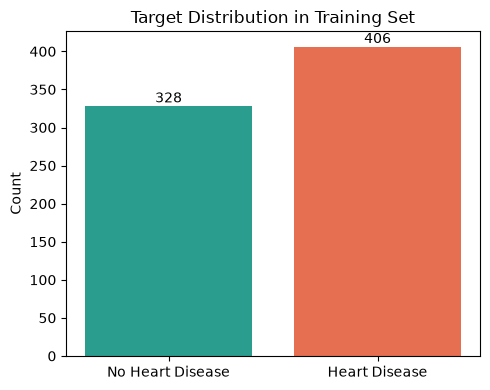

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
target_counts = train_df["HeartDisease"].value_counts().sort_index()
ax.bar(["No Heart Disease", "Heart Disease"], target_counts.values, color=["#2a9d8f", "#e76f51"])
ax.set_title("Target Distribution in Training Set")
ax.set_ylabel("Count")
for idx, value in enumerate(target_counts.values):
    ax.text(idx, value + 5, str(value), ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution_train.png", dpi=150)
plt.show()

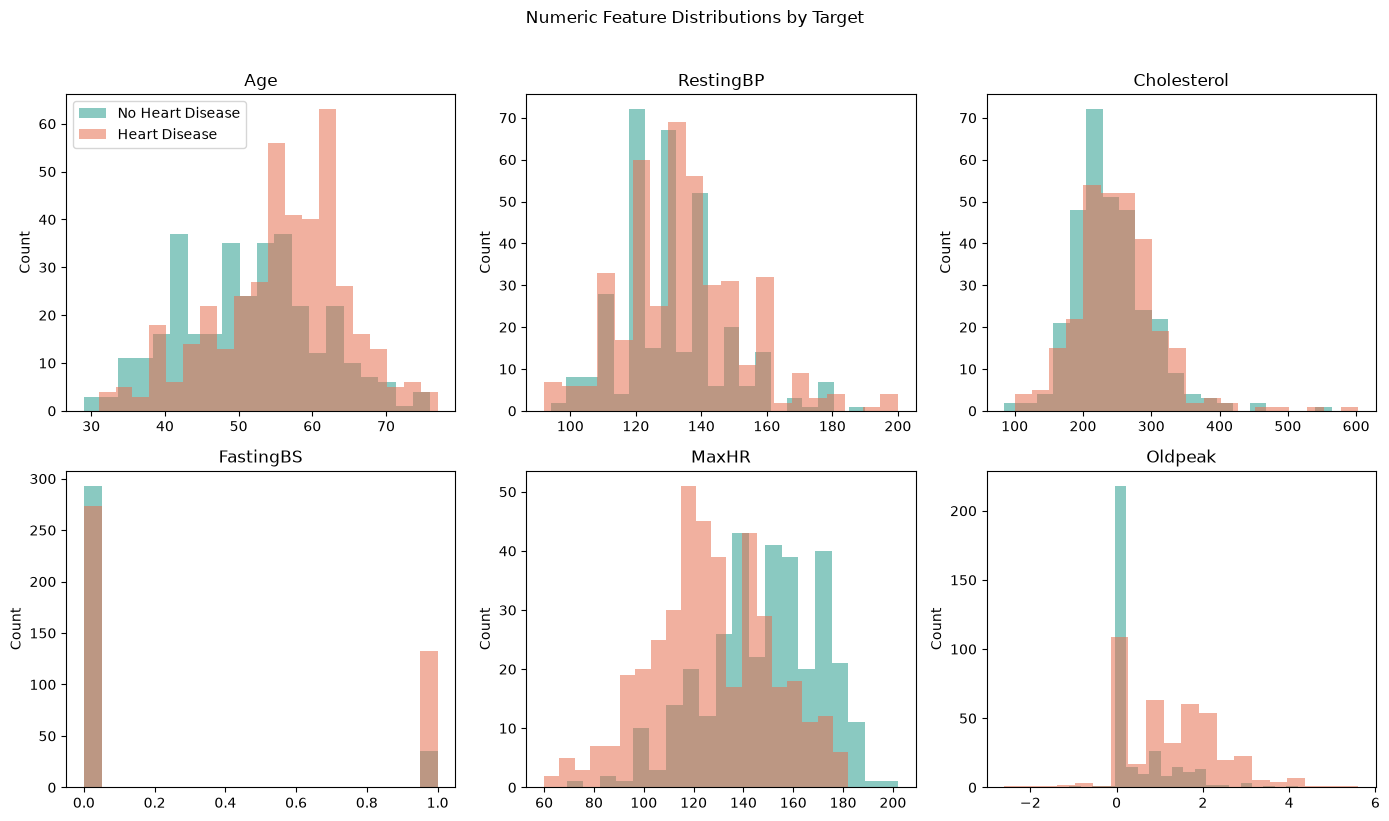

In [10]:
numeric_columns = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, column in zip(axes, numeric_columns):
    for target_value, color, label in [(0, "#2a9d8f", "No Heart Disease"), (1, "#e76f51", "Heart Disease")]:
        values = train_df.loc[train_df["HeartDisease"] == target_value, column].dropna()
        ax.hist(values, bins=20, alpha=0.55, color=color, label=label)
    ax.set_title(column)
    ax.set_ylabel("Count")

axes[0].legend()
fig.suptitle("Numeric Feature Distributions by Target", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "numeric_distributions_by_target.png", dpi=150, bbox_inches="tight")
plt.show()

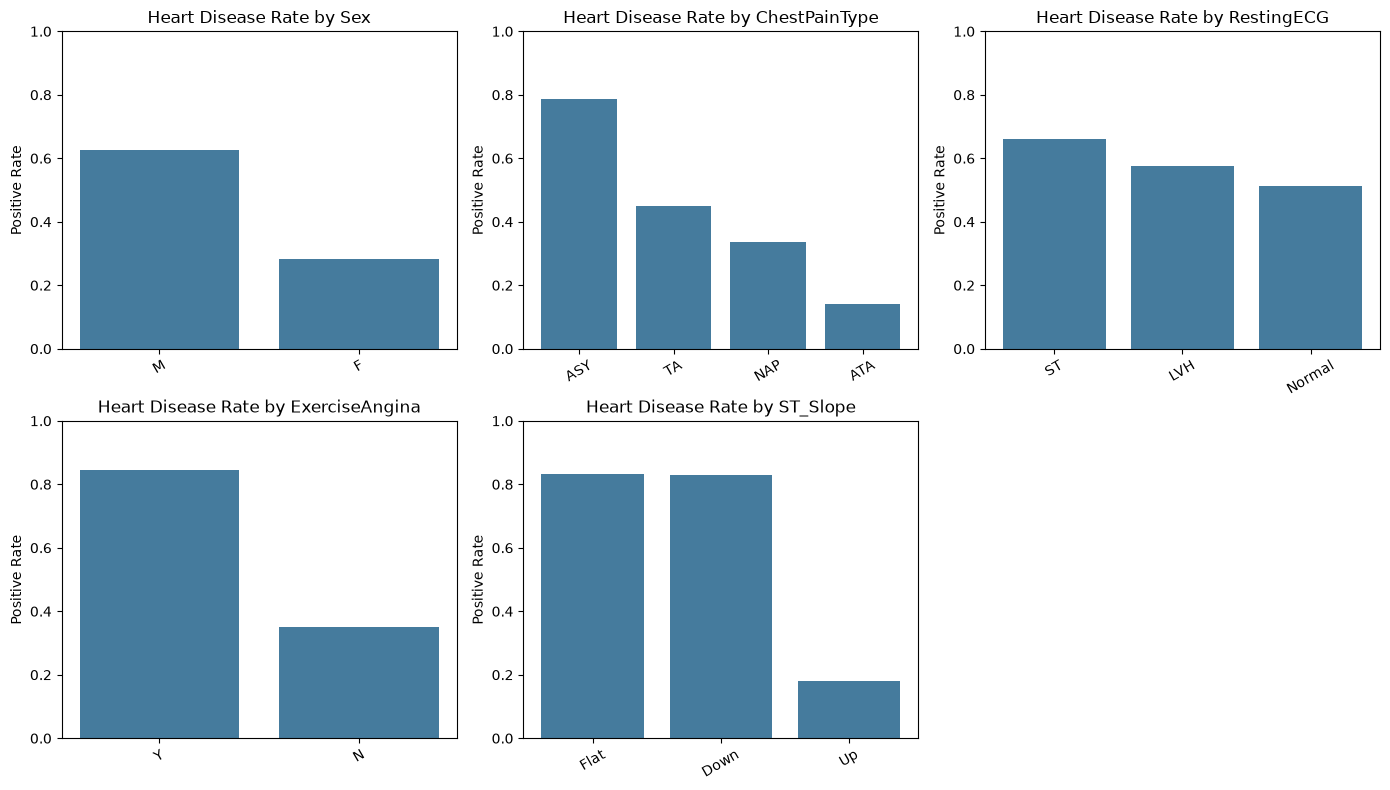

In [11]:
categorical_columns = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, column in zip(axes, categorical_columns):
    rates = train_df.groupby(column)["HeartDisease"].mean().sort_values(ascending=False)
    ax.bar(rates.index.astype(str), rates.values, color="#457b9d")
    ax.set_title(f"Heart Disease Rate by {column}")
    ax.set_ylabel("Positive Rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

axes[-1].axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "categorical_positive_rates_train.png", dpi=150)
plt.show()

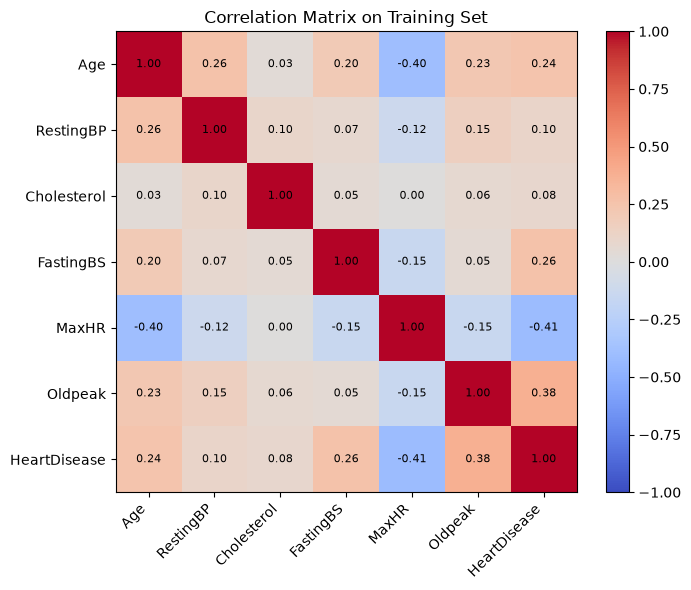

In [12]:
corr_columns = numeric_columns + ["HeartDisease"]
corr = train_df[corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix on Training Set")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_matrix_train.png", dpi=150)
plt.show()

## 7. Preprocessing and Feature Engineering

The preprocessing is inside scikit-learn pipelines:

- Median imputation for numeric features.
- Most-frequent imputation for categorical features.
- Standard scaling for numeric features.
- One-hot encoding for categorical features.

Feature engineering is kept simple and explainable:

- `MaxHRRatio`: achieved maximum heart rate divided by age-based expected maximum heart rate.
- `OldpeakPositive`: whether oldpeak is above zero.
- `ExerciseOldpeak`: interaction between exercise-induced angina and oldpeak.
- `AgeGroup`: broad age group.

In [13]:
def add_engineered_features(X_input):
    X_new = X_input.copy()

    expected_max_hr = 220 - X_new["Age"]
    X_new["MaxHRRatio"] = X_new["MaxHR"] / expected_max_hr.replace(0, np.nan)
    X_new["OldpeakPositive"] = (X_new["Oldpeak"] > 0).astype(int)
    X_new["ExerciseOldpeak"] = X_new["Oldpeak"] * (X_new["ExerciseAngina"] == "Y").astype(int)
    X_new["AgeGroup"] = pd.cut(
        X_new["Age"],
        bins=[0, 45, 55, 65, 120],
        labels=["under_45", "45_55", "56_65", "over_65"],
        include_lowest=True,
    ).astype("object")

    return X_new


numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "MaxHRRatio",
    "OldpeakPositive",
    "ExerciseOldpeak",
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "AgeGroup",
]

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ]
)


def make_pipeline(model):
    return Pipeline(steps=[
        ("features", FunctionTransformer(add_engineered_features, validate=False)),
        ("preprocess", preprocessor),
        ("model", model),
    ])

## 8. Baseline and Model Comparison

The first comparison uses 5-fold stratified cross-validation on the training set only. The test set is still untouched.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "Random Forest": make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)),
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    row = {"model": model_name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
display(cv_results.round(4))

cv_results.to_csv(METRICS_DIR / "cross_validation_model_comparison.csv", index=False)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random Forest,0.8501,0.0272,0.8593,0.0435,0.8771,0.0459,0.8663,0.0229,0.9287,0.0280
0,Logistic Regression,0.8447,0.0215,0.8568,0.0382,0.8670,0.0237,0.8610,0.0156,0.9255,0.0307
1,Decision Tree,0.8160,0.0372,0.8429,0.0431,0.8228,0.0412,0.8320,0.0333,0.8153,0.0382


## 9. Hyperparameter Tuning

Tuning is done with `GridSearchCV` on the training set only. The search is intentionally moderate because the dataset is small and the project should stay reproducible.

In [15]:
tuning_jobs = {
    "Logistic Regression": {
        "pipeline": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        "params": {
            "model__C": [0.1, 1.0, 3.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Decision Tree": {
        "pipeline": make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
        "params": {
            "model__max_depth": [3, 4, 5, None],
            "model__min_samples_leaf": [1, 4, 8],
            "model__criterion": ["gini"],
        },
    },
    "Random Forest": {
        "pipeline": make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [4, 8, None],
            "model__min_samples_leaf": [1, 4],
            "model__max_features": ["sqrt"],
        },
    },
}

tuned_rows = []
tuned_models = {}

for model_name, config in tuning_jobs.items():
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring=scoring,
        refit="roc_auc",
        cv=cv,
        n_jobs=1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    tuned_models[model_name] = search.best_estimator_

    tuned_rows.append({
        "model": model_name,
        "best_roc_auc_cv": search.best_score_,
        "best_params": search.best_params_,
        "mean_train_roc_auc": search.cv_results_["mean_train_roc_auc"][search.best_index_],
        "mean_cv_accuracy": search.cv_results_["mean_test_accuracy"][search.best_index_],
        "mean_cv_precision": search.cv_results_["mean_test_precision"][search.best_index_],
        "mean_cv_recall": search.cv_results_["mean_test_recall"][search.best_index_],
        "mean_cv_f1": search.cv_results_["mean_test_f1"][search.best_index_],
    })

tuned_results = pd.DataFrame(tuned_rows).sort_values("best_roc_auc_cv", ascending=False)
display(tuned_results)

tuned_results_to_save = tuned_results.copy()
tuned_results_to_save["best_params"] = tuned_results_to_save["best_params"].astype(str)
tuned_results_to_save.to_csv(METRICS_DIR / "tuned_model_results.csv", index=False)

,model,best_roc_auc_cv,best_params,mean_train_roc_auc,mean_cv_accuracy,mean_cv_precision,mean_cv_recall,mean_cv_f1
2,Random Forest,0.934552,"{'model__max_depth': None, 'model__max_feature...",0.982158,0.854254,0.854353,0.891749,0.871640
0,Logistic Regression,0.925524,"{'model__C': 1.0, 'model__class_weight': None}",0.932964,0.844712,0.856833,0.867028,0.860954
1,Decision Tree,0.909046,"{'model__criterion': 'gini', 'model__max_depth...",0.921946,0.833837,0.868331,0.837609,0.848606


In [16]:
best_model_name = tuned_results.iloc[0]["model"]
final_model = tuned_models[best_model_name]

print("Selected final model:", best_model_name)
print("Best CV ROC-AUC:", round(tuned_results.iloc[0]["best_roc_auc_cv"], 4))
print("Best parameters:", tuned_results.iloc[0]["best_params"])

Selected final model: Random Forest
Best CV ROC-AUC: 0.9346
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 100}


## 10. Final Evaluation on Held-Out Test Set

The final model is evaluated once on the test set after model selection is finished.

In [17]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "selected_model": best_model_name,
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_precision": precision_score(y_test, y_pred),
    "test_recall": recall_score(y_test, y_pred),
    "test_f1": f1_score(y_test, y_pred),
    "test_roc_auc": roc_auc_score(y_test, y_proba),
}

display(pd.DataFrame([final_metrics]).round(4))
print(classification_report(y_test, y_pred, target_names=["No Heart Disease", "Heart Disease"]))

with open(METRICS_DIR / "final_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)

,selected_model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Random Forest,0.8696,0.8679,0.902,0.8846,0.9173


                  precision    recall  f1-score   support

No Heart Disease       0.87      0.83      0.85        82
   Heart Disease       0.87      0.90      0.88       102

        accuracy                           0.87       184
       macro avg       0.87      0.87      0.87       184
    weighted avg       0.87      0.87      0.87       184



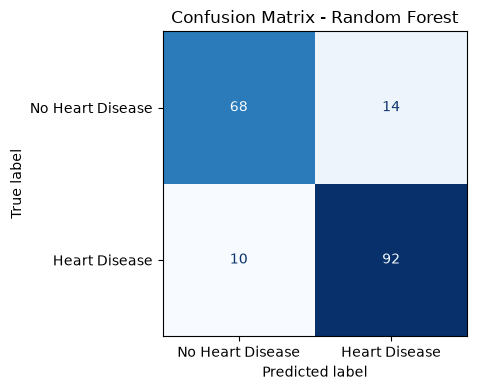

In [18]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["No Heart Disease", "Heart Disease"]).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "final_confusion_matrix.png", dpi=150)
plt.show()

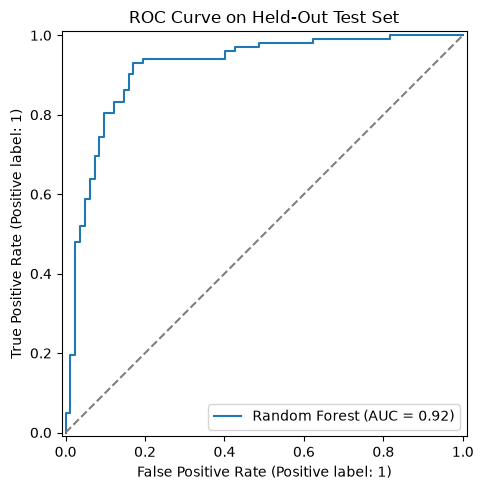

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=best_model_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve on Held-Out Test Set")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "final_roc_curve.png", dpi=150)
plt.show()

In [20]:
predictions = X_test.copy()
predictions["actual_HeartDisease"] = y_test
predictions["predicted_HeartDisease"] = y_pred
predictions["predicted_probability_HeartDisease"] = y_proba
predictions.to_csv(METRICS_DIR / "final_test_predictions.csv", index=False)

display(predictions.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,actual_HeartDisease,predicted_HeartDisease,predicted_probability_HeartDisease
356,46,M,ASY,115.0,NaN,0,Normal,113,Y,1.5,Flat,1,1,0.966029
763,58,M,NAP,132.0,224.0,0,LVH,173,N,3.2,Up,1,0,0.231490
817,60,M,ASY,125.0,258.0,0,LVH,141,Y,2.8,Flat,1,1,0.954519
735,49,M,NAP,120.0,188.0,0,Normal,139,N,2.0,Flat,1,1,0.609396
892,39,F,NAP,138.0,220.0,0,Normal,152,N,0.0,Flat,0,0,0.390397


## 11. Results Summary

The final model is selected based on cross-validation ROC-AUC on the training set, then evaluated once on the held-out test set.

The important point is not only the final accuracy. The result should be judged using precision, recall, F1-score, ROC-AUC, and the confusion matrix because false negatives and false positives have different meanings in this problem.

In [21]:
summary_table = pd.DataFrame([
    {
        "section": "dataset",
        "result": f"{df.shape[0]} rows, {df.shape[1] - 1} features, 1 target",
    },
    {
        "section": "cleaning",
        "result": "RestingBP=0 and Cholesterol=0 treated as missing values",
    },
    {
        "section": "validation",
        "result": "5-fold stratified CV on training set, held-out test set used once",
    },
    {
        "section": "selected_model",
        "result": best_model_name,
    },
    {
        "section": "test_metrics",
        "result": (
            f"Accuracy={final_metrics['test_accuracy']:.3f}, "
            f"F1={final_metrics['test_f1']:.3f}, "
            f"ROC-AUC={final_metrics['test_roc_auc']:.3f}"
        ),
    },
])

display(summary_table)
summary_table.to_csv(METRICS_DIR / "project_summary.csv", index=False)

,section,result
0,dataset,"918 rows, 11 features, 1 target"
1,cleaning,RestingBP=0 and Cholesterol=0 treated as missi...
2,validation,"5-fold stratified CV on training set, held-out..."
3,selected_model,Random Forest
4,test_metrics,"Accuracy=0.870, F1=0.885, ROC-AUC=0.917"


## 12. Limitations

- The dataset is a merged heart disease dataset, but the row source is not available as a feature.
- The target is heart disease presence/absence in the available record, not a future follow-up outcome.
- `Cholesterol = 0` appears often, so it is handled as missing instead of a real measurement.
- The model is useful for an ML classification project, but it should not be used as medical advice.
- More reliable deployment would need stronger external validation on newer clinical data.


## 13. Phase 2: Unsupervised Learning Extension

This section applies the week-five unsupervised learning ideas on the same project. The goal here is different from the classification model above.

In the supervised part, the model learned from `HeartDisease`. In this extension, clustering is fitted without using `HeartDisease`. The target is added back only after the clusters are created, so I can interpret whether some patient groups have higher heart-disease rates.


In [22]:
from sklearn.base import clone
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

### 13.1 Prepare Features for Unsupervised Learning

I reuse the same cleaned training features and the same preprocessing logic. The important point is that `HeartDisease` is not included in the matrix used by `PCA` or `KMeans`.

The preprocessing still handles missing numeric values, scales numeric features, and one-hot encodes categorical features. This is needed because clustering depends on distances between rows.


In [23]:
unsup_features_train = add_engineered_features(X_train)
unsup_preprocessor = clone(preprocessor)
X_unsup = unsup_preprocessor.fit_transform(unsup_features_train)

if hasattr(X_unsup, "toarray"):
    X_unsup = X_unsup.toarray()

print("Unsupervised feature matrix shape:", X_unsup.shape)


Unsupervised feature matrix shape: (734, 27)


The matrix now contains the original usable features plus the engineered features after imputation, scaling, and encoding. The number of columns is larger than the original dataset because categorical columns are expanded with one-hot encoding.


### 13.2 PCA Visualization

`PCA` is used here mainly for visualization. The original preprocessed feature space has many columns after one-hot encoding, so I reduce it to two principal components to see whether the records form visible groups.

This plot is exploratory. It does not prove clinical groups by itself, but it helps show whether the feature space has structure before clustering.


,component,explained_variance_ratio,explained_variance_pct
0,PC1,0.2743,27.4345
1,PC2,0.1455,14.5451


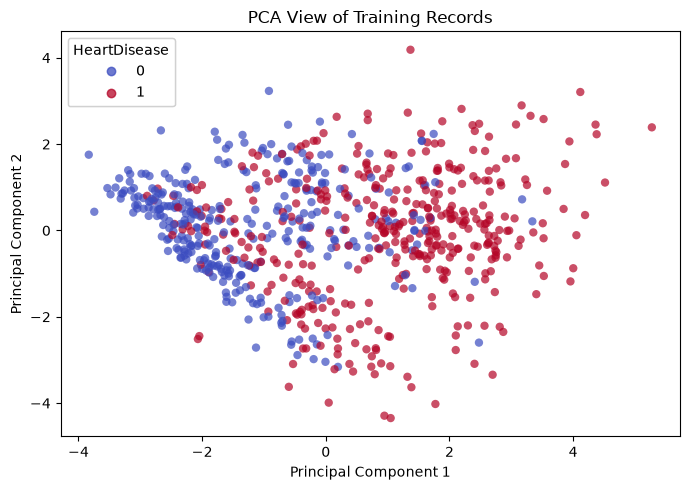

In [24]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_unsup)

pca_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_2d.explained_variance_ratio_,
    "explained_variance_pct": pca_2d.explained_variance_ratio_ * 100,
})

display(pca_variance.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.70,
    edgecolor="none",
)
ax.set_title("PCA View of Training Records")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
legend = ax.legend(*scatter.legend_elements(), title="HeartDisease")
ax.add_artist(legend)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_pca_training_view.png", dpi=150, bbox_inches="tight")
plt.show()


The `PCA` view shows the training records in two dimensions. The colors are not used during `PCA`; they are shown only to check whether the existing target has some visible relation with the main feature directions.

If the two colors overlap, that is normal. Medical tabular data is usually not separated perfectly in two dimensions. The supervised model can still perform well because it uses the full feature space, not only these two components.


### 13.3 Choose the Number of Clusters

For `KMeans`, I test several values of `k`. I look at two signals:

- `inertia`: lower is better, but it always decreases as `k` increases.
- `silhouette_score`: higher is better, and it measures how separated the clusters are.

I use the silhouette score as the main automatic choice because it gives a clearer numeric comparison between candidate cluster counts.


,k,inertia,silhouette_score
0,2,7194.7453,0.1902
1,3,6474.5379,0.1690
2,4,5898.8973,0.1639
3,5,5590.3448,0.1602
4,6,5373.4568,0.1337
5,7,5147.1596,0.1223
6,8,4987.3285,0.1220


Selected k: 2


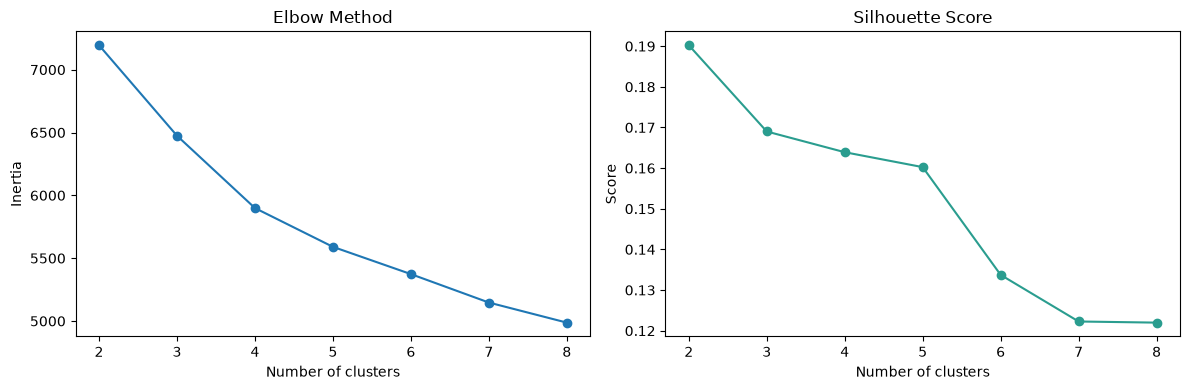

In [25]:
k_values = range(2, 9)
k_selection_rows = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(X_unsup)
    k_selection_rows.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_unsup, cluster_labels),
    })

k_selection = pd.DataFrame(k_selection_rows)
display(k_selection.round(4))

best_k = int(k_selection.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Selected k:", best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_selection["k"], k_selection["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_selection["k"], k_selection["silhouette_score"], marker="o", color="#2a9d8f")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Score")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_kmeans_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

k_selection.to_csv(METRICS_DIR / "phase2_kmeans_k_selection.csv", index=False)


The selected `k` is the cluster count with the highest silhouette score in the tested range. This is not a medical ground truth; it is a data-driven way to choose a reasonable number of groups for exploratory analysis.


### 13.4 Fit KMeans and Profile the Clusters

After choosing `k`, I fit the final `KMeans` model on the preprocessed training features. Then I attach the cluster labels back to the readable training data.

Only at this stage I add `HeartDisease` for interpretation. This lets me describe each cluster and check whether some clusters contain a higher percentage of heart-disease records.


In [26]:
final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
train_clusters = final_kmeans.fit_predict(X_unsup)

clustered_train = X_train.copy()
clustered_train["cluster"] = train_clusters
clustered_train["HeartDisease"] = y_train

cluster_summary = clustered_train.groupby("cluster").agg(
    size=("HeartDisease", "size"),
    heart_disease_rate=("HeartDisease", "mean"),
    avg_age=("Age", "mean"),
    avg_resting_bp=("RestingBP", "mean"),
    avg_cholesterol=("Cholesterol", "mean"),
    fasting_bs_rate=("FastingBS", "mean"),
    avg_max_hr=("MaxHR", "mean"),
    avg_oldpeak=("Oldpeak", "mean"),
    exercise_angina_rate=("ExerciseAngina", lambda s: (s == "Y").mean()),
)

cluster_summary["heart_disease_pct"] = cluster_summary["heart_disease_rate"] * 100
cluster_summary["exercise_angina_pct"] = cluster_summary["exercise_angina_rate"] * 100

cluster_summary_display = cluster_summary[[
    "size",
    "heart_disease_pct",
    "avg_age",
    "avg_resting_bp",
    "avg_cholesterol",
    "fasting_bs_rate",
    "avg_max_hr",
    "avg_oldpeak",
    "exercise_angina_pct",
]].round(2)

display(cluster_summary_display)
cluster_summary_display.to_csv(METRICS_DIR / "phase2_cluster_profile.csv")


,size,heart_disease_pct,avg_age,avg_resting_bp,avg_cholesterol,fasting_bs_rate,avg_max_hr,avg_oldpeak,exercise_angina_pct
cluster,,,,,,,,,
0,325,86.46,57.84,137.29,252.38,0.32,121.5,1.63,78.15
1,409,30.56,50.68,129.37,242.52,0.15,148.2,0.26,11.25


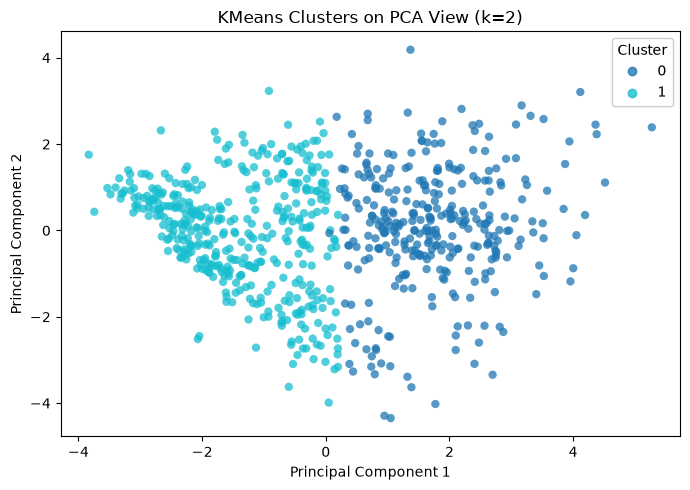

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=train_clusters,
    cmap="tab10",
    alpha=0.75,
    edgecolor="none",
)
ax.set_title(f"KMeans Clusters on PCA View (k={best_k})")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_kmeans_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()


The cluster profile is the most important output in this extension. It translates the unsupervised result from just cluster numbers into understandable patient groups.

A useful interpretation is based on differences such as heart-disease percentage, average `Oldpeak`, `MaxHR`, age, and exercise-induced angina rate. If one cluster has clearly higher `heart_disease_pct`, that means the unsupervised algorithm found a group whose feature pattern is more associated with heart disease, even though the target was not used during clustering.


### 13.5 Hierarchical Clustering

`Hierarchical Clustering` is added as another clustering comparison method. Unlike `KMeans`, it does not start with random centroids. It builds a hierarchy by repeatedly merging the closest groups. I use Ward linkage because it works well with Euclidean distance on scaled numeric features.

The dendrogram gives a visual view of the merge structure, and then I compare candidate cluster counts using silhouette score.

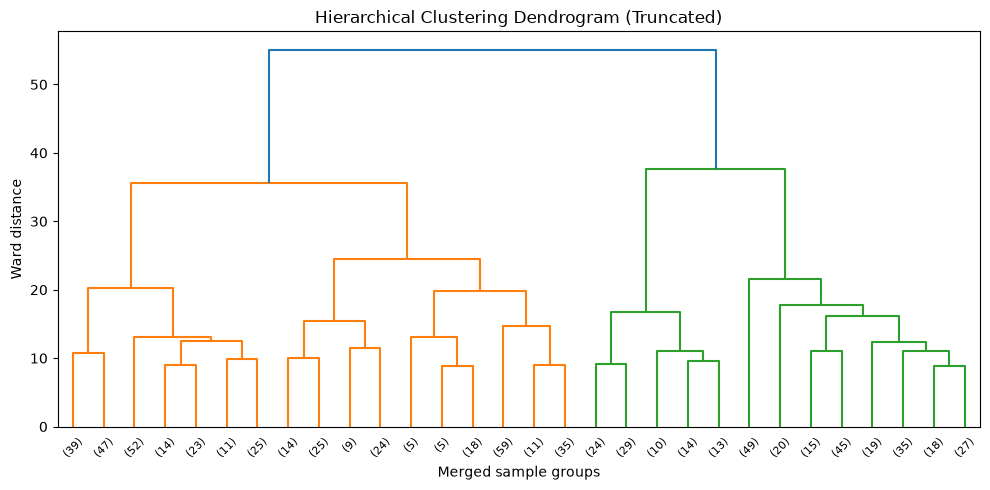

,k,silhouette_score
0,2,0.1630
1,3,0.1507
2,4,0.1470
3,5,0.1512
4,6,0.1368
5,7,0.1005
6,8,0.1084


Selected hierarchical k: 2


In [28]:
hierarchical_linkage = linkage(X_unsup, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    hierarchical_linkage,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=8,
    ax=ax,
)
ax.set_title("Hierarchical Clustering Dendrogram (Truncated)")
ax.set_xlabel("Merged sample groups")
ax.set_ylabel("Ward distance")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_hierarchical_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

hierarchical_rows = []
for k in range(2, 9):
    hierarchical_candidate = AgglomerativeClustering(n_clusters=k, linkage="ward")
    candidate_labels = hierarchical_candidate.fit_predict(X_unsup)
    hierarchical_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_unsup, candidate_labels),
    })

hierarchical_selection = pd.DataFrame(hierarchical_rows)
display(hierarchical_selection.round(4))

best_hierarchical_k = int(
    hierarchical_selection.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
)
print("Selected hierarchical k:", best_hierarchical_k)

hierarchical_selection.to_csv(METRICS_DIR / "phase2_hierarchical_k_selection.csv", index=False)

,size,heart_disease_pct,avg_age,avg_max_hr,avg_oldpeak,exercise_angina_pct
hierarchical_cluster,,,,,,
0,318,85.85,56.86,116.80,1.34,79.56
1,416,31.97,51.55,151.34,0.50,11.30


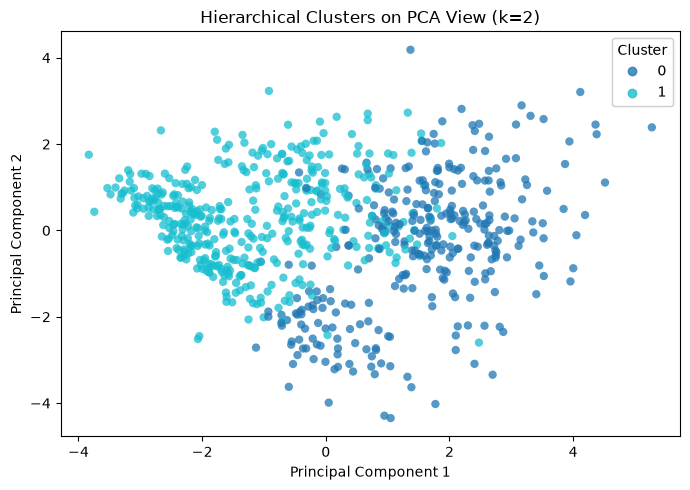

In [29]:
final_hierarchical = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward",
)
hierarchical_labels = final_hierarchical.fit_predict(X_unsup)

hierarchical_profile = X_train.copy()
hierarchical_profile["hierarchical_cluster"] = hierarchical_labels
hierarchical_profile["HeartDisease"] = y_train

hierarchical_summary = hierarchical_profile.groupby("hierarchical_cluster").agg(
    size=("HeartDisease", "size"),
    heart_disease_rate=("HeartDisease", "mean"),
    avg_age=("Age", "mean"),
    avg_max_hr=("MaxHR", "mean"),
    avg_oldpeak=("Oldpeak", "mean"),
    exercise_angina_rate=("ExerciseAngina", lambda s: (s == "Y").mean()),
)

hierarchical_summary["heart_disease_pct"] = hierarchical_summary["heart_disease_rate"] * 100
hierarchical_summary["exercise_angina_pct"] = hierarchical_summary["exercise_angina_rate"] * 100

hierarchical_summary_display = hierarchical_summary[[
    "size",
    "heart_disease_pct",
    "avg_age",
    "avg_max_hr",
    "avg_oldpeak",
    "exercise_angina_pct",
]].round(2)

display(hierarchical_summary_display)
hierarchical_summary_display.to_csv(METRICS_DIR / "phase2_hierarchical_cluster_profile.csv")

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hierarchical_labels,
    cmap="tab10",
    alpha=0.75,
    edgecolor="none",
)
ax.set_title(f"Hierarchical Clusters on PCA View (k={best_hierarchical_k})")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_hierarchical_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

The hierarchical result is useful because it gives an independent clustering comparison. If it also prefers two clusters and produces a similar high-risk versus lower-risk profile, that supports the interpretation found by `KMeans`. It still remains exploratory because no clustering method here receives the target label during fitting.

### 13.6 DBSCAN Density-Based Clustering

`DBSCAN` is added as a second clustering method for comparison with `KMeans`. Unlike `KMeans`, it does not require choosing `k` in advance. It groups dense regions and labels sparse points as noise using `-1`.

Because this dataset is tabular and becomes relatively high-dimensional after one-hot encoding, `DBSCAN` is expected to be sensitive to `eps` and `min_samples`. I test a small grid of values and select a reasonable setting using non-noise silhouette score while avoiding extreme noise rates.

In [30]:
dbscan_rows = []

for eps in np.arange(1.5, 3.01, 0.25):
    for min_samples in [5, 10, 15]:
        dbscan_candidate = DBSCAN(eps=float(eps), min_samples=min_samples)
        candidate_labels = dbscan_candidate.fit_predict(X_unsup)
        non_noise_mask = candidate_labels != -1

        n_clusters = len(set(candidate_labels)) - (1 if -1 in candidate_labels else 0)
        n_noise = int((candidate_labels == -1).sum())
        noise_pct = n_noise / len(candidate_labels) * 100

        silhouette_non_noise = np.nan
        if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
            silhouette_non_noise = silhouette_score(
                X_unsup[non_noise_mask],
                candidate_labels[non_noise_mask],
            )

        dbscan_rows.append({
            "eps": float(eps),
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": noise_pct,
            "silhouette_non_noise": silhouette_non_noise,
        })

dbscan_results = pd.DataFrame(dbscan_rows)
display(dbscan_results.round(4))

valid_dbscan = dbscan_results[
    (dbscan_results["n_clusters"] >= 2)
    & (dbscan_results["noise_pct"] <= 50)
    & (dbscan_results["silhouette_non_noise"].notna())
]

if valid_dbscan.empty:
    selected_dbscan = dbscan_results.sort_values(
        ["n_clusters", "noise_pct"],
        ascending=[False, True],
    ).iloc[0]
else:
    selected_dbscan = valid_dbscan.sort_values(
        ["silhouette_non_noise", "noise_pct"],
        ascending=[False, True],
    ).iloc[0]

best_dbscan_eps = float(selected_dbscan["eps"])
best_dbscan_min_samples = int(selected_dbscan["min_samples"])

print("Selected DBSCAN eps:", best_dbscan_eps)
print("Selected DBSCAN min_samples:", best_dbscan_min_samples)

final_dbscan = DBSCAN(eps=best_dbscan_eps, min_samples=best_dbscan_min_samples)
dbscan_labels = final_dbscan.fit_predict(X_unsup)

print("DBSCAN clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("DBSCAN noise points:", int((dbscan_labels == -1).sum()))
print("DBSCAN noise percentage:", round((dbscan_labels == -1).mean() * 100, 2))

dbscan_results.to_csv(METRICS_DIR / "phase2_dbscan_parameter_search.csv", index=False)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_non_noise
0,1.50,5,6,640,87.1935,0.1921
1,1.50,10,2,713,97.1390,0.2754
2,1.50,15,0,734,100.0000,NaN
3,1.75,5,7,488,66.4850,0.1545
4,1.75,10,2,590,80.3815,0.4622
5,1.75,15,2,675,91.9619,0.2290
6,2.00,5,11,318,43.3243,0.0915
7,2.00,10,2,474,64.5777,0.3828
8,2.00,15,2,510,69.4823,0.4220
9,2.25,5,7,191,26.0218,-0.0220


Selected DBSCAN eps: 2.25
Selected DBSCAN min_samples: 10
DBSCAN clusters: 2
DBSCAN noise points: 288
DBSCAN noise percentage: 39.24


,size,heart_disease_pct,avg_age,avg_max_hr,avg_oldpeak,exercise_angina_pct
dbscan_cluster,,,,,,
-1,288,61.46,56.62,134.69,1.03,33.33
0,412,47.57,51.46,138.53,0.70,41.26
1,34,97.06,59.35,124.53,1.42,100.00


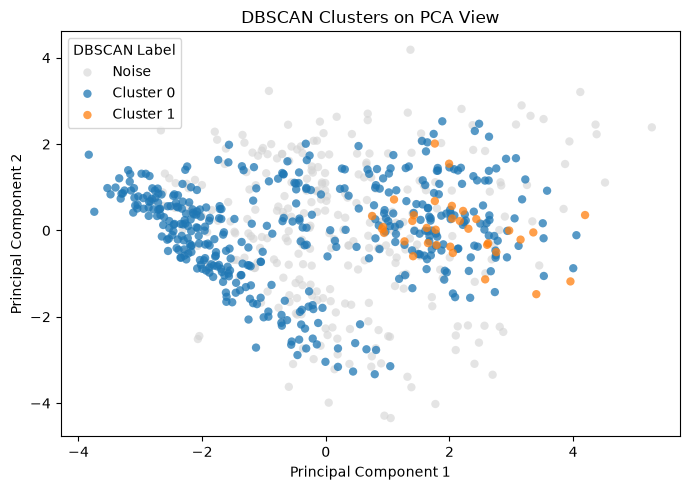

In [31]:
dbscan_profile = X_train.copy()
dbscan_profile["dbscan_cluster"] = dbscan_labels
dbscan_profile["HeartDisease"] = y_train

dbscan_summary = dbscan_profile.groupby("dbscan_cluster").agg(
    size=("HeartDisease", "size"),
    heart_disease_rate=("HeartDisease", "mean"),
    avg_age=("Age", "mean"),
    avg_max_hr=("MaxHR", "mean"),
    avg_oldpeak=("Oldpeak", "mean"),
    exercise_angina_rate=("ExerciseAngina", lambda s: (s == "Y").mean()),
)

dbscan_summary["heart_disease_pct"] = dbscan_summary["heart_disease_rate"] * 100
dbscan_summary["exercise_angina_pct"] = dbscan_summary["exercise_angina_rate"] * 100

dbscan_summary_display = dbscan_summary[[
    "size",
    "heart_disease_pct",
    "avg_age",
    "avg_max_hr",
    "avg_oldpeak",
    "exercise_angina_pct",
]].round(2)

display(dbscan_summary_display)
dbscan_summary_display.to_csv(METRICS_DIR / "phase2_dbscan_cluster_profile.csv")

fig, ax = plt.subplots(figsize=(7, 5))

for label in sorted(np.unique(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        ax.scatter(
            X_pca_2d[mask, 0],
            X_pca_2d[mask, 1],
            color="lightgray",
            alpha=0.60,
            edgecolor="none",
            label="Noise",
        )
    else:
        ax.scatter(
            X_pca_2d[mask, 0],
            X_pca_2d[mask, 1],
            alpha=0.75,
            edgecolor="none",
            label=f"Cluster {label}",
        )

ax.set_title("DBSCAN Clusters on PCA View")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="DBSCAN Label")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_dbscan_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

The `DBSCAN` result is useful as a comparison point. If it returns many noise points, that does not mean the code is wrong. It means the density structure is not as clean for this tabular, one-hot encoded feature space. In this project, `KMeans` remains easier to explain as patient segmentation, while `DBSCAN` is better interpreted as a density/noise check.

### 13.7 t-SNE Visualization

`t-SNE` is used only for visualization. Unlike `PCA`, which preserves global variance through linear components, `t-SNE` focuses more on local neighborhoods. This can make small groups visually clearer, but the axes themselves are not directly interpretable.

I use the already preprocessed feature matrix and color the result by the `KMeans` cluster labels, then by the true `HeartDisease` label only for interpretation.

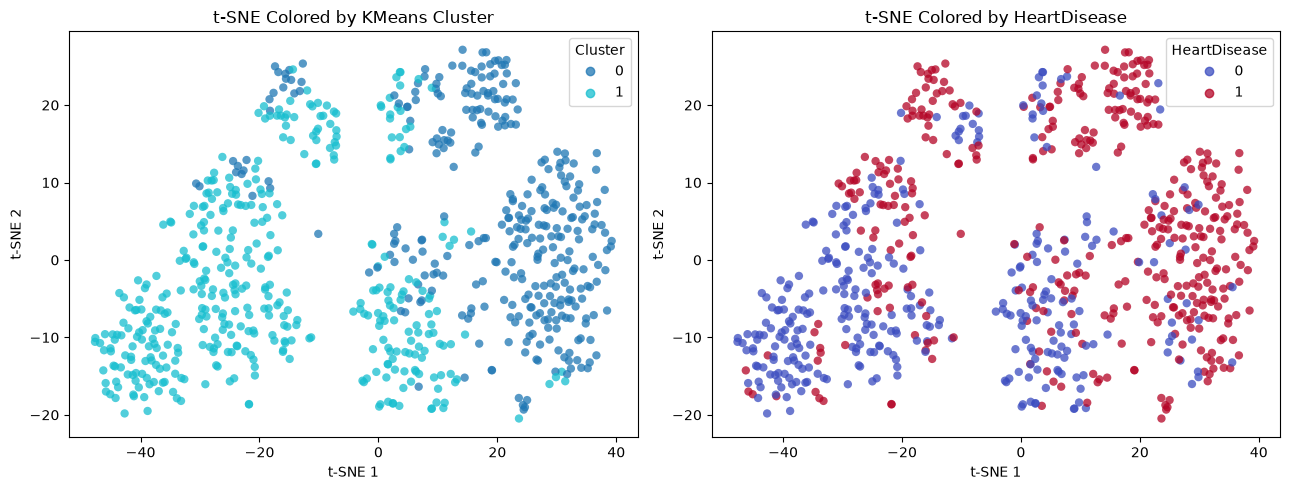

In [32]:
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE,
).fit_transform(X_unsup)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter_clusters = axes[0].scatter(
    tsne_2d[:, 0],
    tsne_2d[:, 1],
    c=train_clusters,
    cmap="tab10",
    alpha=0.75,
    edgecolor="none",
)
axes[0].set_title("t-SNE Colored by KMeans Cluster")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(*scatter_clusters.legend_elements(), title="Cluster")

scatter_target = axes[1].scatter(
    tsne_2d[:, 0],
    tsne_2d[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.75,
    edgecolor="none",
)
axes[1].set_title("t-SNE Colored by HeartDisease")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(*scatter_target.legend_elements(), title="HeartDisease")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_tsne_training_view.png", dpi=150, bbox_inches="tight")
plt.show()

The `t-SNE` plot is not used as input to the model. It is a visual diagnostic: it helps compare whether local neighborhoods in the feature space agree with the `KMeans` clusters or with the original target distribution. The interpretation should stay cautious because `t-SNE` can change with hyperparameters such as perplexity and random initialization.

### 13.8 Isolation Forest Anomaly Detection

`Isolation Forest` is used for unsupervised anomaly detection. It learns the normal structure of the feature space and flags records that are easier to isolate as anomalies.

I set `contamination=0.05`, meaning the model is asked to flag roughly 5% of the training records as unusual. This is a modeling assumption, not a medical truth.

In [33]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
)

anomaly_predictions = isolation_forest.fit_predict(X_unsup)
anomaly_scores = isolation_forest.decision_function(X_unsup)
is_anomaly = anomaly_predictions == -1

print("Anomaly count:", int(is_anomaly.sum()))
print("Anomaly percentage:", round(is_anomaly.mean() * 100, 2))

anomaly_profile = X_train.copy()
anomaly_profile["is_anomaly"] = is_anomaly
anomaly_profile["anomaly_score"] = anomaly_scores
anomaly_profile["HeartDisease"] = y_train

anomaly_summary = anomaly_profile.groupby("is_anomaly").agg(
    size=("HeartDisease", "size"),
    heart_disease_rate=("HeartDisease", "mean"),
    avg_age=("Age", "mean"),
    avg_resting_bp=("RestingBP", "mean"),
    avg_cholesterol=("Cholesterol", "mean"),
    avg_max_hr=("MaxHR", "mean"),
    avg_oldpeak=("Oldpeak", "mean"),
    exercise_angina_rate=("ExerciseAngina", lambda s: (s == "Y").mean()),
)

anomaly_summary["heart_disease_pct"] = anomaly_summary["heart_disease_rate"] * 100
anomaly_summary["exercise_angina_pct"] = anomaly_summary["exercise_angina_rate"] * 100

anomaly_summary_display = anomaly_summary[[
    "size",
    "heart_disease_pct",
    "avg_age",
    "avg_resting_bp",
    "avg_cholesterol",
    "avg_max_hr",
    "avg_oldpeak",
    "exercise_angina_pct",
]].round(2)

display(anomaly_summary_display)
anomaly_summary_display.to_csv(METRICS_DIR / "phase2_isolation_forest_profile.csv")

top_anomalies = anomaly_profile.sort_values("anomaly_score").head(5)[[
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope",
    "HeartDisease",
    "anomaly_score",
]]

display(top_anomalies.round(3))
top_anomalies.to_csv(METRICS_DIR / "phase2_top_anomalies.csv", index=False)

Anomaly count: 37
Anomaly percentage: 5.04


,size,heart_disease_pct,avg_age,avg_resting_bp,avg_cholesterol,avg_max_hr,avg_oldpeak,exercise_angina_pct
is_anomaly,,,,,,,,
False,697,55.67,53.60,132.42,245.70,136.47,0.83,40.60
True,37,48.65,58.51,141.51,262.55,134.57,1.50,45.95


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,anomaly_score
732,56,F,ASY,200.0,288.0,1,LVH,133,Y,4.0,Down,1,-0.066
619,74,F,ATA,120.0,269.0,0,LVH,121,Y,0.2,Up,0,-0.050
733,66,F,TA,150.0,226.0,0,Normal,114,N,2.6,Down,0,-0.039
541,76,M,NAP,104.0,113.0,0,LVH,120,N,3.5,Down,1,-0.039
537,74,M,ASY,150.0,258.0,1,ST,130,Y,4.0,Down,1,-0.038


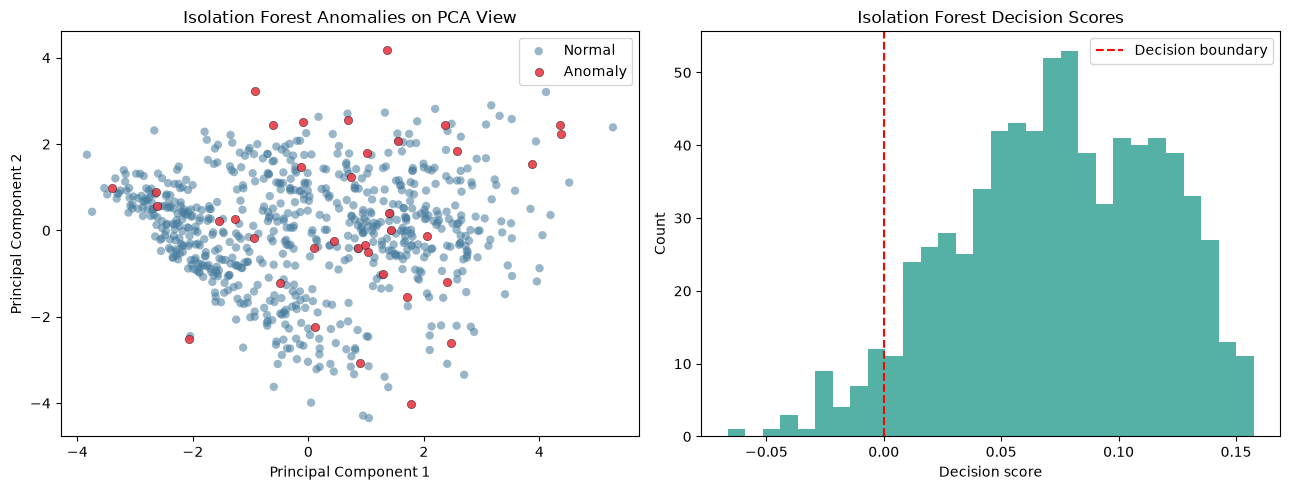

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    X_pca_2d[~is_anomaly, 0],
    X_pca_2d[~is_anomaly, 1],
    color="#457b9d",
    alpha=0.55,
    edgecolor="none",
    label="Normal",
)
axes[0].scatter(
    X_pca_2d[is_anomaly, 0],
    X_pca_2d[is_anomaly, 1],
    color="#e63946",
    alpha=0.90,
    edgecolor="black",
    linewidth=0.3,
    label="Anomaly",
)
axes[0].set_title("Isolation Forest Anomalies on PCA View")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

axes[1].hist(anomaly_scores, bins=30, color="#2a9d8f", alpha=0.80)
axes[1].axvline(0, color="red", linestyle="--", label="Decision boundary")
axes[1].set_title("Isolation Forest Decision Scores")
axes[1].set_xlabel("Decision score")
axes[1].set_ylabel("Count")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase2_isolation_forest_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

The anomalies are not automatically wrong records or heart-disease cases. They are records with unusual combinations of features compared with the rest of the training data. This makes `Isolation Forest` useful for review and data-quality investigation, but not a replacement for the supervised classifier.

### 13.9 Phase 2 Summary

This extension applies the main Week 5 unsupervised learning methods to the same heart disease dataset. The supervised model remains the final classifier, while `PCA`, `KMeans`, `Hierarchical Clustering`, `DBSCAN`, `t-SNE`, and `Isolation Forest` are used for exploration, patient subgroup analysis, visualization, density comparison, and anomaly detection.

The key technical point is avoiding leakage: `HeartDisease` is not used to build the clusters, visual embeddings, or anomaly detector. It is used only afterward to profile and understand the discovered groups.